In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import xarray as xr
import matplotlib.pyplot as plt
import statsmodels.api as sm
import scipy.stats as stats
import matplotlib.cm as cm
import matplotlib.colors as mcolors
import networkx as nx

In [2]:
def df_xr_prep(df):
    da=df.to_xarray()
    da=da.rename({'index':'year'})
    return da

##La Plata
#SON
era_SON_LaPlata_df=pd.read_csv('~/work/data_ready/7_with_VB.csv',index_col='Unnamed: 0')

#era_SON_LaPlata_df=era_SON_LaPlata_df.rename(index_col='year')
era_SON_LaPlata_array=era_SON_LaPlata_df.to_xarray()
era_SON_LaPlata_array=era_SON_LaPlata_array.rename({'index':'year'})

#DJF
era_DJF_LaPlata_df=pd.read_csv('~/work/data_ready/6_with_IOBW_VB.csv', index_col='Unnamed: 0')
era_DJF_LaPlata_array=df_xr_prep(era_DJF_LaPlata_df)

##Andes
#SON
era_SON_Andes_df=pd.read_csv('~/work/data_ready/5_with_VB.csv',index_col='Unnamed: 0')
era_SON_Andes_array=df_xr_prep(era_SON_Andes_df)

#DJF
era_DJF_Andes_df=pd.read_csv('~/work/data_ready/4_with_IOBW_VB.csv', index_col='Unnamed: 0')
era_DJF_Andes_array=df_xr_prep(era_DJF_Andes_df)
display(era_DJF_Andes_array)

<xarray.Dataset> Size: 8kB
Dimensions:        (year: 73)
Coordinates:
  * year           (year) int64 584B 1951 1952 1953 1954 ... 2022 2023 2024 1950
Data variables: (12/13)
    t_Andes        (year) float64 584B -1.791 0.5614 -0.2617 ... 0.6017 nan
    precip_Andes   (year) float64 584B 0.129 0.4549 -1.375 ... -0.2223 -1.51 nan
    ENSO           (year) float64 584B -0.6866 0.5838 0.3068 ... 1.632 nan
    IOD            (year) float64 584B 0.2555 0.6281 1.26 ... 0.9651 4.209 nan
    EDJ            (year) float64 584B 1.783 0.6677 -0.5056 ... 0.1875 nan
    EDJ_lat        (year) float64 584B -0.6985 1.359 -0.9556 ... -2.241 nan
    ...             ...
    SPV            (year) float64 584B 0.2633 -0.6312 1.451 ... 1.702 1.85 nan
    A_SAM          (year) float64 584B 0.233 -1.135 -2.197 ... 1.774 0.05365 nan
    S_SAM          (year) float64 584B 0.6038 -1.058 0.1437 ... 1.93 1.88 nan
    IOBW           (year) float64 584B -1.546 0.8591 -0.3374 ... 2.389 nan
    VB             (year) float64 584B -0.0653 -0.101 0.2247 ... 0.7241 nan
    VB_class       (year) object 584B 'Early' 'Early' 'Late' ... 'Late' 'Early'

In [3]:
from Functions import lin_model_fast, conditioning_everything_fast

In [4]:
drivers_SON= ['ENSO', 'IOD', 'SPV', 'A_SAM', 'S_SAM']
drivers_DJF=['ENSO', 'IOBW', 'VB', 'A_SAM', 'S_SAM']
drivers_tot_SON=['ENSO', 'IOD', 'SPV']
drivers_tot_DJF=['ENSO', 'IOBW', 'VB']


##Andes
t_SON_direct=conditioning_everything_fast(era_SON_Andes_array,drivers_SON, 't_Andes')
pr_SON_direct=conditioning_everything_fast(era_SON_Andes_array, drivers_SON, 'precip_Andes')
t_DJF_direct=conditioning_everything_fast(era_DJF_Andes_array, drivers_DJF, 't_Andes')
pr_DJF_direct=conditioning_everything_fast(era_DJF_Andes_array, drivers_DJF, 'precip_Andes')

##La Plata
t_SON_direct_LP=conditioning_everything_fast(era_SON_LaPlata_array, drivers_SON, 't_LaPlata')
pr_SON_direct_LP=conditioning_everything_fast(era_SON_LaPlata_array, drivers_SON, 'precip_LaPlata')
t_DJF_direct_LP=conditioning_everything_fast(era_DJF_LaPlata_array, drivers_DJF, 't_LaPlata')
pr_DJF_direct_LP=conditioning_everything_fast(era_DJF_LaPlata_array, drivers_DJF, 'precip_LaPlata')

ENSO done
IOD done
SPV done
A_SAM done
S_SAM done
ENSO done
IOD done
SPV done
A_SAM done
S_SAM done
ENSO done
IOBW done
VB done
A_SAM done
S_SAM done
ENSO done
IOBW done
VB done
A_SAM done
S_SAM done
ENSO done
IOD done
SPV done
A_SAM done
S_SAM done
ENSO done
IOD done
SPV done
A_SAM done
S_SAM done
ENSO done
IOBW done
VB done
A_SAM done
S_SAM done
ENSO done
IOBW done
VB done
A_SAM done
S_SAM done


Get all the links between drivers and mediators again

In [5]:
##ENSO IOD/IOBW
ENSO_IOD=conditioning_everything_fast(era_SON_Andes_array, ['ENSO'], 'IOD')
ENSO_IOBW=conditioning_everything_fast(era_DJF_Andes_array, ['ENSO'], 'IOBW')

##SPV/VB
SPV_SON_links=conditioning_everything_fast(era_SON_Andes_array, ['ENSO', 'IOD'], 'SPV')
VB_DJF_links=conditioning_everything_fast(era_DJF_Andes_array, ['ENSO', 'IOD'], 'VB')

##A-SAM
A_SAM_SON_links=conditioning_everything_fast(era_SON_Andes_array, ['ENSO', 'IOD'], 'A_SAM')
A_SAM_DJF_links=conditioning_everything_fast(era_DJF_Andes_array, ['ENSO', 'IOD'], 'A_SAM')

##S-SAM
S_SAM_SON_links=conditioning_everything_fast(era_SON_Andes_array, ['ENSO', 'IOD', 'SPV'], 'S_SAM')
S_SAM_DJF_links=conditioning_everything_fast(era_DJF_Andes_array, ['ENSO', 'IOD', 'VB'], 'S_SAM')

spring_driver_links=[ENSO_IOD, SPV_SON_links, A_SAM_SON_links, S_SAM_SON_links]
summer_driver_links=[ENSO_IOBW, VB_DJF_links, A_SAM_DJF_links, S_SAM_DJF_links]

ENSO done
ENSO done
ENSO done
IOD done
ENSO done
IOD done
ENSO done
IOD done
ENSO done
IOD done
ENSO done
IOD done
SPV done
ENSO done
IOD done
VB done


In [12]:
def transform_reg_lists(somelist, driver_target_tuple_list, dict_with_other_info=None, copy_ind=True):
    if copy_ind==True:
        d = {} if dict_with_other_info is None else dict_with_other_info.copy()
    else:
        d = {} if dict_with_other_info is None else dict_with_other_info

    for reg_coef, key in zip(somelist, driver_target_tuple_list):
        d[key] = float(reg_coef.values)

    return d

driver_target_list_SON=[[('ENSO', 'IOD')], [('ENSO', 'SPV'), ('IOD', 'SPV')], [('ENSO', 'A_SAM'), ('IOD', 'A_SAM')],
                    [('ENSO', 'S_SAM'), ('IOD', 'S_SAM'), ('SPV', 'S_SAM')]]
driver_target_list_DJF=[[('ENSO', 'IOBW')], [('ENSO', 'VB'), ('IOBW', 'VB')], [('ENSO', 'A_SAM'), ('IOBW', 'A_SAM')],
                    [('ENSO', 'S_SAM'), ('IOBW', 'S_SAM'), ('VB', 'S_SAM')]]

mod_dict_SON = {}
mod_dict_DJF = {}

for i, element in enumerate(spring_driver_links):

    mod_dict_SON = transform_reg_lists(
        element,
        driver_target_list_SON[i],
        mod_dict_SON, copy_ind=False
    )

    mod_dict_DJF = transform_reg_lists(
        summer_driver_links[i],
        driver_target_list_DJF[i],
        mod_dict_DJF, copy_ind=False
    )

In [13]:
target_vars=['T_Andes', 'Precip_Andes', 'T_LP', 'Precip_LP']
target_reg_coef_list_SON=[t_SON_direct, pr_SON_direct, t_SON_direct_LP, pr_SON_direct_LP]
target_reg_coef_list_DJF=[t_DJF_direct, pr_DJF_direct, t_DJF_direct_LP, pr_DJF_direct_LP]

pos_t_SON = { "ENSO": (0, 2), "SPV": (1.2, 1), 'IOD':(-1.2,1), "S_SAM": (+0.5, .5), "A_SAM": (-0.5, 0.5), 
             "T": (0, -1)} 
pos_precip_SON = { "ENSO": (0, 2), "SPV": (1.2, 1), 'IOD':(-1.2,1), "S_SAM": (+0.5, .5),
                   "A_SAM": (-0.5, 0.5), "Precip": (0, -1)} 
pos_t_DJF = { "ENSO": (0, 2), "VB": (1.2, 1), 'IOBW':(-1.2,1), "S_SAM": (+0.5, .5), 
             "A_SAM": (-0.5, 0.5), "T": (0, -1)}
pos_precip_DJF = { "ENSO": (0, 2), "VB": (1.2, 1), 'IOBW':(-1.2,1), "S_SAM": (+0.5, .5),
                   "A_SAM": (-0.5, 0.5), "Precip": (0, -1)}

d_SON={}
d_DJF={}
for i in range(len(target_vars)):
    target_tuple_list=[(driver, target_vars[i]) for driver in drivers_SON]
    target_tuple_list_DJF=[(driver, target_vars[i]) for driver in drivers_DJF]
    SON_target_dict=transform_reg_lists(target_reg_coef_list_SON[i],target_tuple_list, mod_dict_SON)
    DJF_target_dict=transform_reg_lists(target_reg_coef_list_DJF[i], target_tuple_list_DJF, mod_dict_DJF)
    #print(SON_target_dict)
    d_SON[target_vars[i]]=SON_target_dict
    d_DJF[target_vars[i]]=DJF_target_dict


print(d_SON)

from drawing_dag import plot_causal_networks_grid

var_type = target_vars[i].split("_")[0]
positions_list = []

for i, var in enumerate(target_vars):
    var_type = var.split("_")[0]   # T or Precip

    # SON block
    if var_type == "T":
        positions_list.append(pos_t_SON)
    else:
        positions_list.append(pos_precip_SON)

# DJF block (same order appended after SON)
for i, var in enumerate(target_vars):
    var_type = var.split("_")[0]

    if var_type == "T":
        positions_list.append(pos_t_DJF)
    else:
        positions_list.append(pos_precip_DJF)



network_data_list=list(d_SON.values())+list(d_DJF.values())
title_list = []

for var in target_vars:
    region = var.split("_")[1]

    title_list.append(f"{var.split('_')[0]} {region}")   # SON
for var in target_vars:
    region = var.split("_")[1]

    title_list.append(f"{var.split('_')[0]} {region}")   # DJF

    
positions_list=[pos_t_SON, pos_precip_SON, pos_t_SON, pos_precip_SON,
                 pos_t_DJF, pos_precip_DJF, pos_t_DJF, pos_precip_DJF]


print(network_data_list)

{'T_Andes': {('ENSO', 'IOD'): 0.5506543942116933, ('ENSO', 'SPV'): -0.07755565731904662, ('IOD', 'SPV'): 0.05357633646698273, ('ENSO', 'A_SAM'): -0.5711811995787874, ('IOD', 'A_SAM'): -0.25404293462274175, ('ENSO', 'S_SAM'): -0.04758306947479939, ('IOD', 'S_SAM'): -0.08453594390678636, ('SPV', 'S_SAM'): 0.7197426693884648, ('ENSO', 'T_Andes'): 0.10614060344648284, ('IOD', 'T_Andes'): -0.07954292899853112, ('SPV', 'T_Andes'): 0.06365197525474021, ('A_SAM', 'T_Andes'): 0.36166785759056114, ('S_SAM', 'T_Andes'): -0.013507502919819557}, 'Precip_Andes': {('ENSO', 'IOD'): 0.5506543942116933, ('ENSO', 'SPV'): -0.07755565731904662, ('IOD', 'SPV'): 0.05357633646698273, ('ENSO', 'A_SAM'): -0.5711811995787874, ('IOD', 'A_SAM'): -0.25404293462274175, ('ENSO', 'S_SAM'): -0.04758306947479939, ('IOD', 'S_SAM'): -0.08453594390678636, ('SPV', 'S_SAM'): 0.7197426693884648, ('ENSO', 'Precip_Andes'): 0.13501608414989957, ('IOD', 'Precip_Andes'): -0.024915371942104282, ('SPV', 'Precip_Andes'): -0.199208724

/home/glattus/work/whole_period_effects/drawing_dag.py:98: UserWarning: You have used the `textcoords` kwarg, but not the `xytext` kwarg.  This can lead to surprising results.
  ax.annotate(


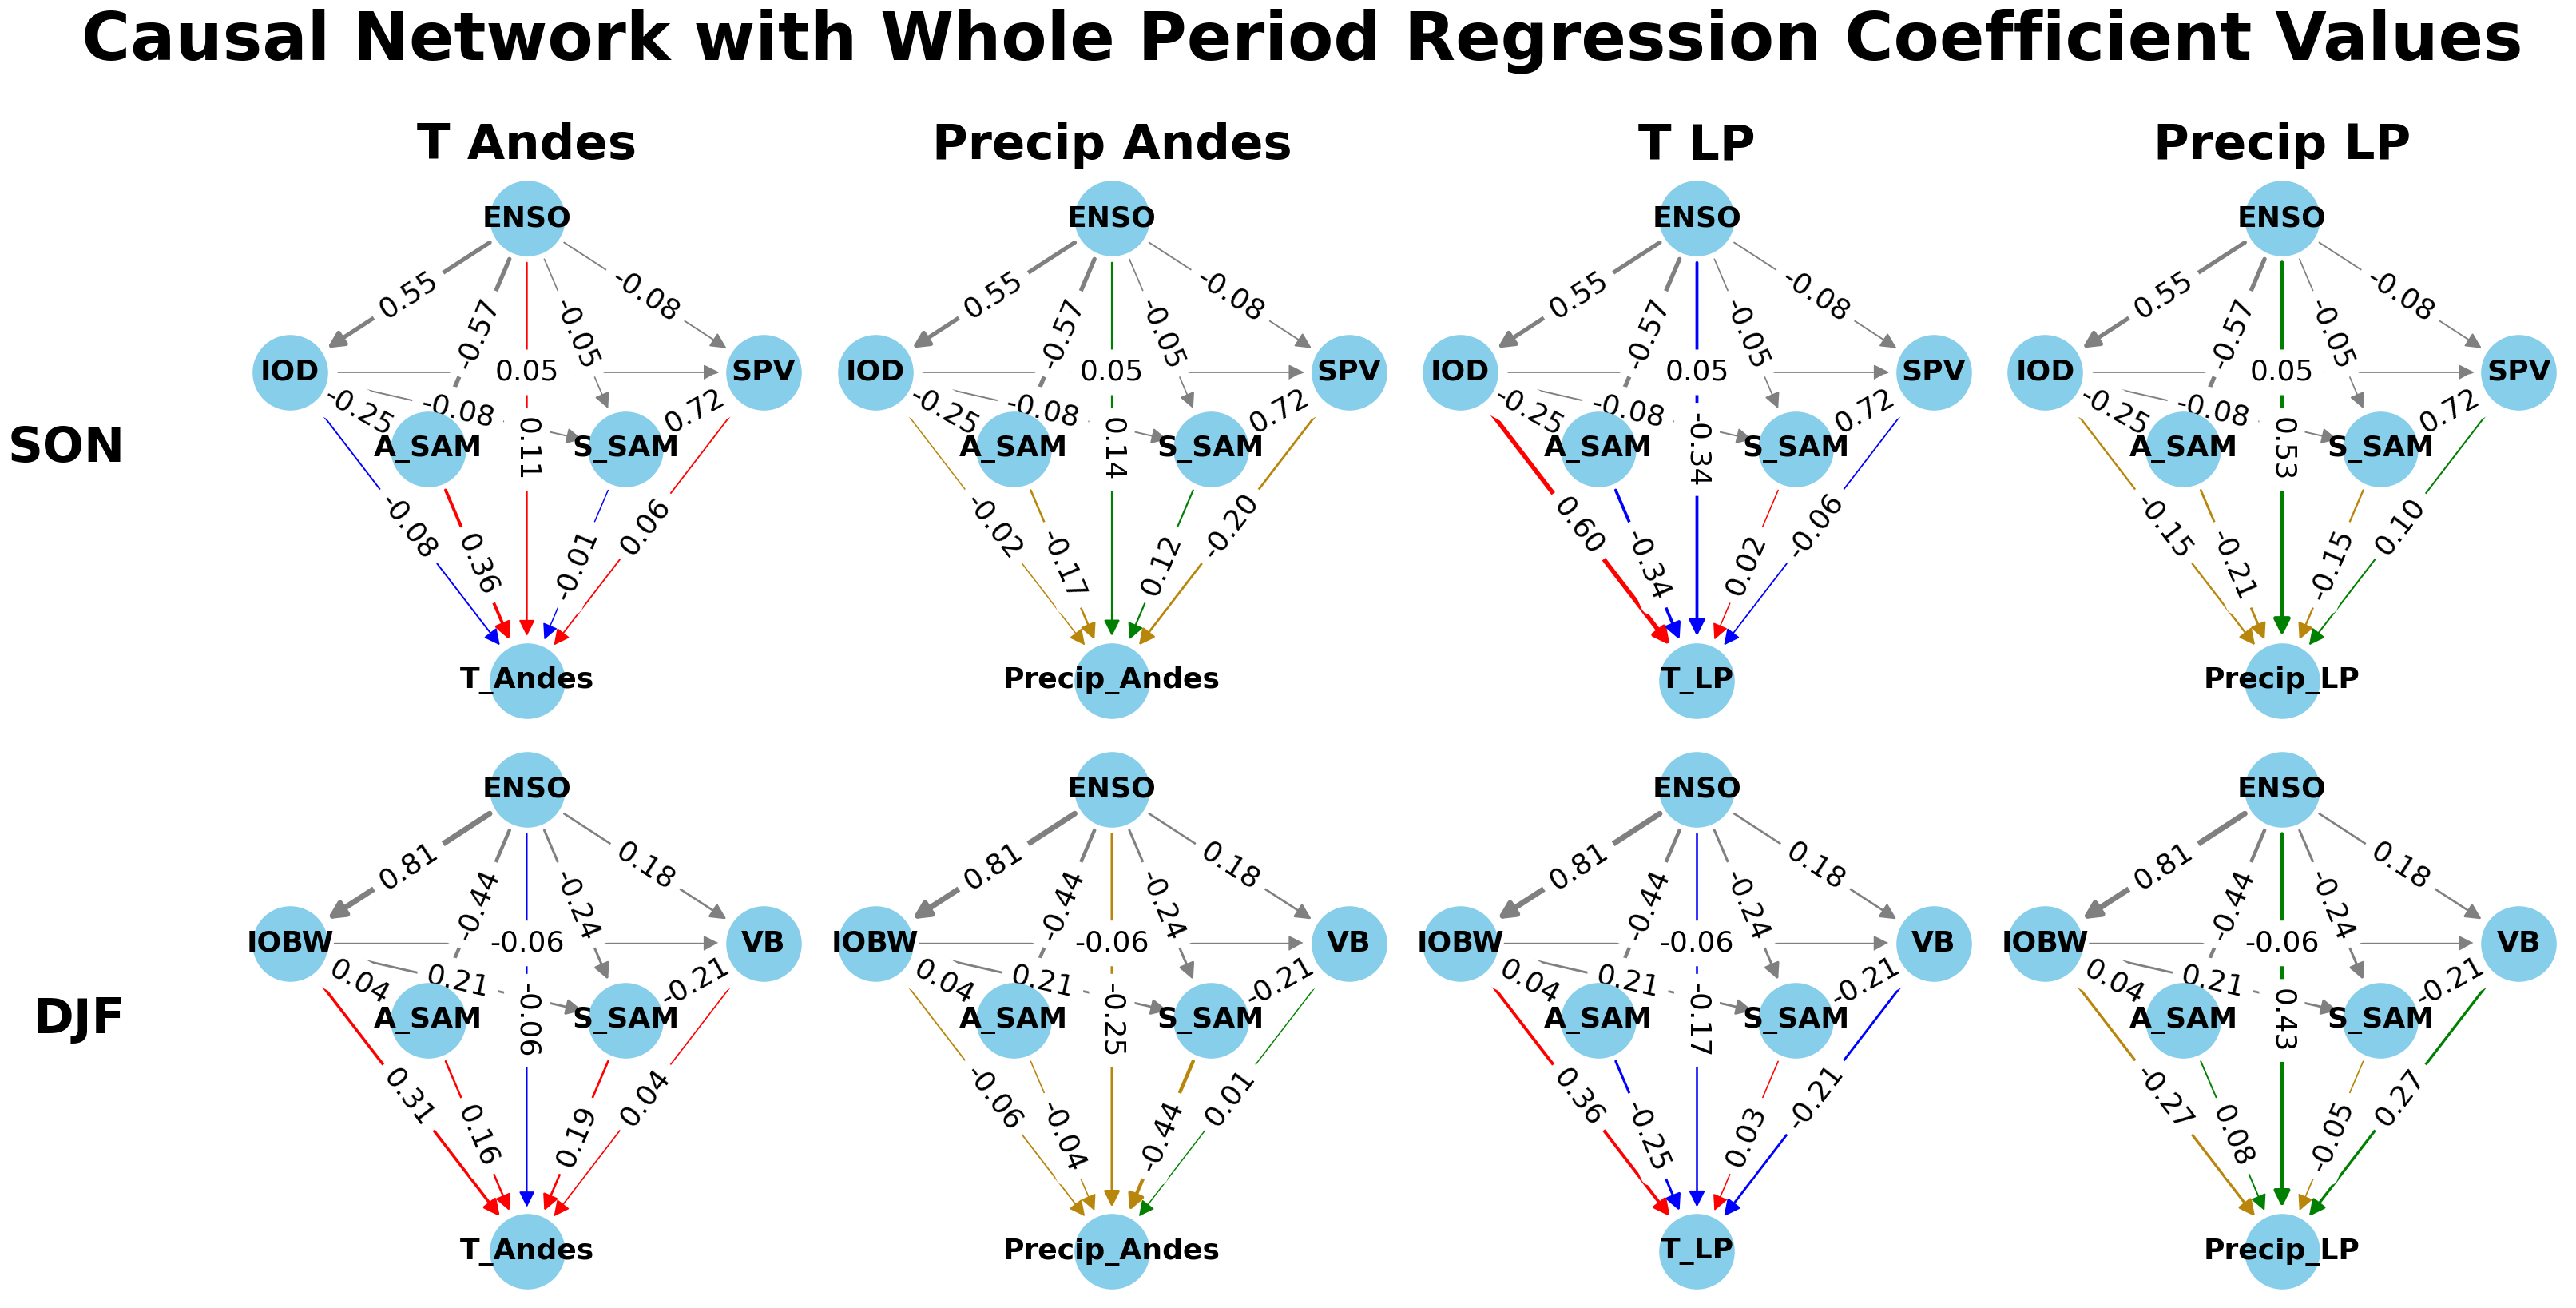

In [14]:
plot_causal_networks_grid(network_data_list, positions_list, title_list, row_labels=['SON', 'DJF'])

Cross-seasonal network

In [ ]:
target_vars=['T_Andes', 'Precip_Andes', 'T_LP', 'Precip_LP']

##add cross-seasonal links, fix the values here!
cross_networks = []

for target in target_vars:

    net = {}

    # SON edges
    for (src, dst), val in d_SON[target].items():
        net[(f"{src}_SON", f"{dst}_SON")] = val

    # DJF edges
    for (src, dst), val in d_DJF[target].items():
        net[(f"{src}_DJF", f"{dst}_DJF")] = val

    #add autocorr val for each target
    net.update({(f'{target}_SON', f'{target}_DJF'):1.})

    # Cross-season links of large-sclae drivers
    net.update({
        ("ENSO_SON", "ENSO_DJF"): 1,
        ("SPV_SON", "IOBW_DJF"): 1,
        ("IOD_SON", "VB_DJF"): 1,
    })

    cross_networks.append(net)

In [ ]:
from drawing_dag import plot_causal_networks_two_seasons

pos_seas_t = {
    "ENSO DJF": (3, 2),
    "VB DJF": (4.4, 1.2),
    'IOBW DJF':(1.7,0.6),
    'ENSO SON':(0,2),
    'IOD SON':(-1.3,1),
    'SPV SON':(1.3,1.2),
    'T SON':(0,-1.5),
    "S_SAM DJF": (3.5, 0),
    "A_SAM DJF": (2.5, 0),
    "T DJF": (3, -1.5),
    'S_SAM SON':(0.5,0),
    'A_SAM SON':(-0.5,0)}

pos_seas_pr = {
    "ENSO DJF": (3, 2),
    "VB DJF": (4.4, 1.2),
    'IOBW DJF':(1.7,0.6),
    'ENSO SON':(0,2),
    'IOD SON':(-1.3,1),
    'SPV SON':(1.3,1.2),
    'Precip SON':(0,-1.5),
    "S_SAM DJF": (3.5, 0),
    "A_SAM DJF": (2.5, 0),
    "Precip DJF": (3, -1.5),
    'S_SAM SON':(0.5,0),
    'A_SAM SON':(-0.5,0)}

title_list_cross=[]
for var in target_vars:
    region = var.split("_")[1]

    title_list_cross.append(f"{var.split('_')[0]} {region}")   


In [ ]:
plot_causal_networks_two_seasons(cross_networks, positions_list_cross, title_list_cross, row_labels=['Temperature', 'Precipitation'], figsize=(28,14))

{'T_Andes': {('ENSO', 'IOD'): 0.5506543942116933, ('ENSO', 'SPV'): -0.07755565731904662, ('IOD', 'SPV'): 0.05357633646698273, ('ENSO', 'A_SAM'): -0.5711811995787874, ('IOD', 'A_SAM'): -0.25404293462274175, ('ENSO', 'S_SAM'): -0.04758306947479939, ('IOD', 'S_SAM'): -0.08453594390678636, ('SPV', 'S_SAM'): 0.7197426693884648, ('ENSO SON', 'T_Andes'): 0.10614060344648284, ('IOD SON', 'T_Andes'): -0.07954292899853112, ('SPV SON', 'T_Andes'): 0.06365197525474021, ('A_SAM SON', 'T_Andes'): 0.36166785759056114, ('S_SAM SON', 'T_Andes'): -0.013507502919819557, ('ENSO SON', 'Precip_Andes'): 0.13501608414989957, ('IOD SON', 'Precip_Andes'): -0.024915371942104282, ('SPV SON', 'Precip_Andes'): -0.1992087242518645, ('A_SAM SON', 'Precip_Andes'): -0.1667703494003072, ('S_SAM SON', 'Precip_Andes'): 0.11665079862052903, ('ENSO SON', 'T_LP'): -0.34326539110752174, ('IOD SON', 'T_LP'): 0.602674737887289, ('SPV SON', 'T_LP'): -0.05569508475146852, ('A_SAM SON', 'T_LP'): -0.3426277461639539, ('S_SAM SON', 

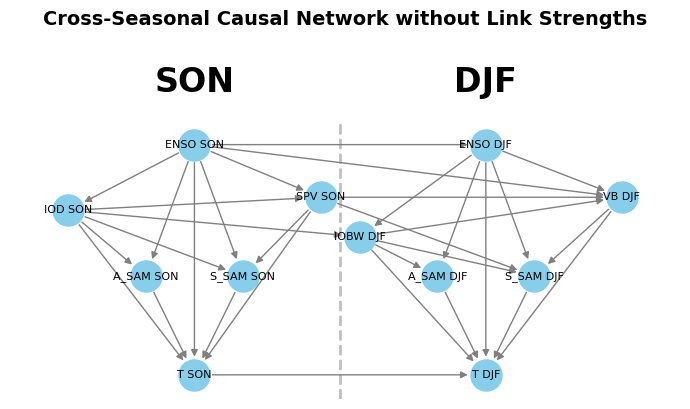

In [ ]:
drivers_cross=['ENSO SON', 'IOD SON', 'SPV SON', 'A_SAM SON', 'S_SAM SON', 
               'ENSO DJF', 'IOBW DJF', 'VB DJF', 'A_SAM DJF', 'S_SAM DJF']



G=nx.DiGraph()
G.add_nodes_from([('ENSO SON',{'color':'blue'}),('IOD SON',{'color':'blue'}), \
                  ('SPV SON',{'color':'blue'}), ('S_SAM SON',{'color':'green'}),\
                  ('A_SAM SON',{'color':'green'}), ('T SON',{'color':'red'}),
                  ('ENSO DJF',{'color':'blue'}),('IOBW DJF',{'color':'blue'}), \
                  ('VB DJF',{'color':'blue'}), ('S_SAM DJF',{'color':'green'}),\
                  ('A_SAM DJF',{'color':'green'}), ('T DJF',{'color':'red'})])

G.add_edges_from([#spring
                    ('ENSO SON', 'IOD SON'), ('IOD SON', 'SPV SON'), ('ENSO SON', 'SPV SON'), \
                  ('ENSO SON', 'A_SAM SON'), ('ENSO SON', 'T SON'), ('ENSO SON', 'S_SAM SON'),\
                 ('IOD SON', 'A_SAM SON'), ('IOD SON', 'S_SAM SON'), ('SPV SON', 'S_SAM SON'),\
                 ('IOD SON', 'T SON'), ('SPV SON', 'T SON'), ('A_SAM SON', 'T SON'), ('S_SAM SON', 'T SON'),
                 #summer
                 ('ENSO DJF', 'IOBW DJF'), ('IOBW DJF', 'VB DJF'), ('ENSO DJF', 'VB DJF'), \
                  ('ENSO DJF', 'A_SAM DJF'), ('ENSO DJF', 'T DJF'), ('ENSO DJF', 'S_SAM DJF'),\
                 ('IOBW DJF', 'A_SAM DJF'), ('IOBW DJF', 'S_SAM DJF'), ('VB DJF', 'S_SAM DJF'),\
                 ('IOBW DJF', 'T DJF'), ('VB DJF', 'T DJF'), ('A_SAM DJF', 'T DJF'), ('S_SAM DJF', 'T DJF'),
                 ##cross-seasonal
                 ('ENSO SON', 'ENSO DJF'), ('IOD SON', 'IOBW DJF'), ('SPV SON', 'VB DJF'), ('SPV SON', 'S_SAM DJF'),
                 ('ENSO SON', 'VB DJF'), ('T SON', 'T DJF')])

elarge = [(u, v) for (u, v, d) in G.edges(data=True)]
# nodes
fig, ax=plt.subplots(figsize=(7, 4))
nx.draw_networkx_nodes(G, pos_seas, node_size=500, node_color='skyblue')
# edges
nx.draw_networkx_edges(G, pos_seas, edgelist=elarge, width=1, edge_color='grey', arrows=True, arrowstyle='-|>', arrowsize=10,
                       min_source_margin=13, min_target_margin=13)
# node labels
nx.draw_networkx_labels(G, pos_seas, font_size=8, font_family="sans-serif")
ax.axvline(
    x=1.5,
    color='grey',
    linestyle='--',
    linewidth=2,
    alpha=0.5
)

ax.axis('off')
ax.text(0, 2.8, "SON", fontsize=24, fontweight='bold', ha='center')
ax.text(3, 2.8, "DJF", fontsize=24, fontweight='bold', ha='center')
fig.suptitle("Cross-Seasonal Causal Network without Link Strengths", y=1.01, fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()